# Phase 3: Text Classification — Classical Model

**Features:** TF-IDF  
**Models:** Multinomial Naive Bayes *(baseline — add more models below)*

**Dataset:** `szzs1693/intro-nlp-thai-news` — 3 categories: `politics`, `economics`, `social`

In [1]:
# Setup Thai font for matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

!wget -q -O thsarabunnew-webfont.ttf https://github.com/PyThaiNLP/prachathai-67k/raw/master/thsarabunnew-webfont.ttf

fm.fontManager.addfont("thsarabunnew-webfont.ttf")
plt.rc('font', family='TH Sarabun New')

In [2]:
import json
import os

import joblib
import numpy as np
import pandas as pd
import seaborn as sns
from datasets import load_dataset
from pythainlp.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from tqdm.auto import tqdm

## 1. Load Dataset

In [3]:
ds = load_dataset("szzs1693/intro-nlp-thai-news")
df = ds["train"].to_pandas()
df.head()

README.md:   0%|          | 0.00/490 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/32.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/6603 [00:00<?, ? examples/s]

,url,date,title,body_text,category,source
0,https://prachatai.com/print/2575,2005-02-03 02:09:00,ปากคำแก๊งหน้าดารา : อันธพาลกวนเมือง หรือ?,คดีซามูไรผมแดงครั้งนั้น กลายเป็นข่าวใหญ่โตทั้ง...,social,prachathai
1,https://prachatai.com/print/4921,2005-07-16 10:17:00,วิษณุแจงออก พ.ร.ก.. ฉุกเฉินเพื่อบูรณาการกฎหมาย,[1]\nประชาไท15 ก.ค. 2548 นายวิษณุ เครืองาม รอ...,politics,prachathai
2,https://prachatai.com/print/4923,2005-07-16 10:18:00,คำอธิบายพระราชกำหนดบริหารราชการในสถานการณ์ฉุกเ...,ภายหลังการประชุมคณะรัฐนตรีนัดพิเศษ นายวิษณุ เค...,politics,prachathai
3,https://prachatai.com/print/4939,2005-07-18 01:49:00,อนุกรรมการสมานฉันท์ฯถกพรก.ฉุกเฉิน,นายอับดุลอาซิซ ตาเดอินทร์ รองนายกสมาคมยุวมุสลิ...,politics,prachathai
4,https://prachatai.com/print/4945,2005-07-18 16:26:00,"โพลระบุ ""คน 3 จว.ใต้-กทม."" หนุนรัฐออกกม.สถานกา...",สำนักวิจัยเอแบคโพลล์ มหาวิทยาลัยอัสสัมชัญ ได้ส...,politics,prachathai


In [4]:
print(f"Shape: {df.shape}")
print(f"\nNull values:\n{df.isnull().sum()}")
print(f"\nDtypes:\n{df.dtypes}")

Shape: (6603, 6)

Null values:
url          0
date         0
title        0
body_text    0
category     0
source       0
dtype: int64

Dtypes:
url                     str
date         datetime64[us]
title                   str
body_text               str
category                str
source                  str
dtype: object


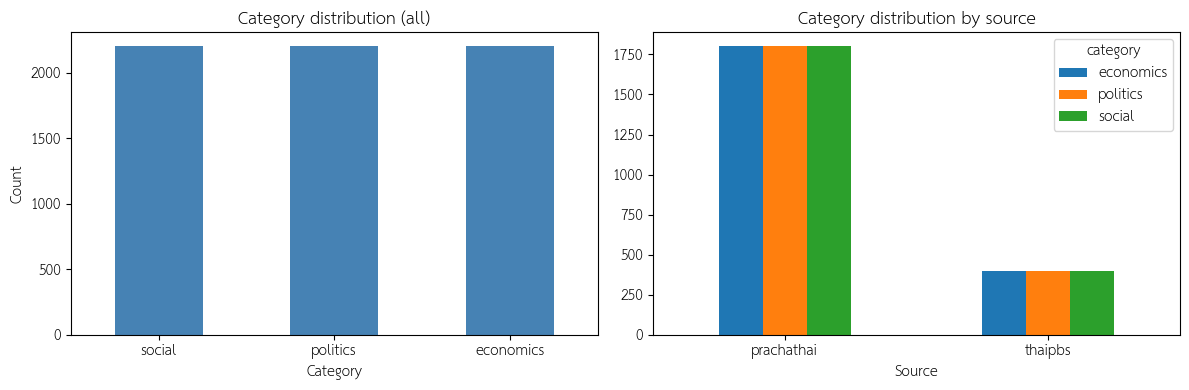

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["category"].value_counts().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Category distribution (all)")
axes[0].set_xlabel("Category")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)

df.groupby("source")["category"].value_counts().unstack().plot(kind="bar", ax=axes[1])
axes[1].set_title("Category distribution by source")
axes[1].set_xlabel("Source")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

## 2. Preprocessing

Thai text has no spaces between words, so we must perform **word segmentation** before vectorization.

We use `pythainlp`'s `newmm` engine (dictionary-based maximum matching), then join the tokens with spaces so that `TfidfVectorizer` can treat each token as a word.

In [6]:
def tokenize(text: str) -> str:
    tokens = word_tokenize(text, engine="newmm", keep_whitespace=False)
    return " ".join(tokens)

In [7]:
# This cell is slow (~5–10 min depending on hardware). Run once and proceed.
tqdm.pandas(desc="Tokenizing")
df["tokenized_text"] = df["body_text"].progress_apply(tokenize)

Tokenizing:   0%|          | 0/6603 [00:00<?, ?it/s]

In [8]:
# Sanity check — compare raw vs tokenized for one article
sample = df.iloc[0]
print("=== RAW (first 300 chars) ===")
print(sample["body_text"][:300])
print("\n=== TOKENIZED (first 300 chars) ===")
print(sample["tokenized_text"][:300])

=== RAW (first 300 chars) ===
คดีซามูไรผมแดงครั้งนั้น กลายเป็นข่าวใหญ่โตทั้งหนังสือพิมพ์ วิทยุและทีวี ทำให้คนรู้จักกลุ่มของพวกเราไปทั้งประเทศ ผมไม่อยากพูดถึง เพราะมันเป็นความผิดที่ทำให้เราถูกเกลียดชัง ถูกจับจ้องมองทั้งจากตำรวจและจากแหล่งสื่อต่างๆ
คดีที่เกิดขึ้นหลายครั้งต่อมา ทั้งสื่อ ตำรวจ และสังคมต่างพากันประโคมข่าวว่า เป็นกลุ่

=== TOKENIZED (first 300 chars) ===
คดี ซามูไร ผม แดง ครั้งนั้น กลาย เป็นข่าว ใหญ่โต ทั้ง หนังสือพิมพ์ วิทยุ และ ทีวี ทำให้ คนรู้จัก กลุ่ม ของ พวกเรา ไป ทั้ง ประเทศ ผม ไม่ อยาก พูดถึง เพราะ มัน เป็นความ ผิดที่ ทำให้ เรา ถูก เกลียดชัง ถูกจับ จ้องมอง ทั้ง จาก ตำรวจ และ จาก แหล่ง สื่อ ต่างๆ 
 คดี ที่ เกิดขึ้น หลาย ครั้งต่อมา ทั้ง สื่อ ตำ


## 3. Train / Validation / Test Split

We use a **70 / 15 / 15** stratified split to preserve class balance across all three sets.

> **Rule:** fit all preprocessing (TF-IDF) on the **train set only**, then transform val and test.

In [9]:
X = df["tokenized_text"]
y = df["category"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")
print("\nClass distribution per split:")
for split_name, split_y in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    print(f"\n{split_name}:")
    print(split_y.value_counts().to_string())

Train: 4622 | Val: 990 | Test: 991

Class distribution per split:

Train:
category
politics     1541
economics    1541
social       1540

Val:
category
economics    330
politics     330
social       330

Test:
category
social       331
politics     330
economics    330


## 4. TF-IDF Feature Extraction

Key parameters:
- `max_features=50000` — caps vocabulary size to the top 50k terms by frequency
- `sublinear_tf=True` — applies log normalization to term frequency, reducing the dominance of very frequent words

In [10]:
tfidf = TfidfVectorizer(max_features=50_000, sublinear_tf=True)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

print(f"Vocabulary size: {len(tfidf.vocabulary_):,}")
print(f"Train matrix shape: {X_train_tfidf.shape}")

Vocabulary size: 31,980
Train matrix shape: (4622, 31980)


## 5. Model Training & Evaluation

`results` and `trained_models` accumulate as you add more models below.  
Re-run the comparison table cell after each new model to see updated results.

In [11]:
results = {}        # { model_name: { accuracy, precision, recall, f1 } }
trained_models = {} # { model_name: fitted_model }

In [12]:
def train_and_evaluate(name: str, model, X_train, y_train, X_val, y_val) -> None:
    """Train model, evaluate on validation set, and store results globally."""
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)

    metrics = {
        "accuracy":  accuracy_score(y_val, y_pred),
        "precision": precision_score(y_val, y_pred, average="macro"),
        "recall":    recall_score(y_val, y_pred, average="macro"),
        "f1":        f1_score(y_val, y_pred, average="macro"),
    }

    print(f"[{name}] Validation results:")
    for k, v in metrics.items():
        print(f"  {k:10s}: {v:.4f}")

    trained_models[name] = model
    results[name] = metrics

### Naive Bayes

`MultinomialNB` is the classic probabilistic baseline for text classification.
It models each category as a word frequency distribution and classifies by maximum likelihood.

In [13]:
train_and_evaluate(
    "Naive Bayes",
    MultinomialNB(),
    X_train_tfidf, y_train,
    X_val_tfidf, y_val,
)

[Naive Bayes] Validation results:
  accuracy  : 0.7808
  precision : 0.7883
  recall    : 0.7808
  f1        : 0.7740


#### Discussion

*(Fill in after running the cell above)*

- Which category has the highest / lowest recall? Why might that be?
- Are precision and recall balanced, or is the model biased toward one class?
- Does accuracy alone tell the full story here?

---

### Next models to try

Add a code cell below for each model, then re-run the **Comparison Table**.  
Import the class and pass it to `train_and_evaluate` — everything else is already wired up.

| Model | Import | Notes |
|---|---|---|
| **Logistic Regression** | `from sklearn.linear_model import LogisticRegression` | Strong general baseline; set `max_iter=1000` |
| **LinearSVC** | `from sklearn.svm import LinearSVC` | Typically best for high-dimensional sparse text features |

**Template:**
```python
from sklearn.linear_model import LogisticRegression

train_and_evaluate(
    "Logistic Regression",
    LogisticRegression(max_iter=1000),
    X_train_tfidf, y_train,
    X_val_tfidf, y_val,
)
```

### Comparison Table

Re-run this cell after adding each new model.

In [14]:
comparison = pd.DataFrame(results).T
comparison.index.name = "Model"
comparison.style.highlight_max(axis=0, color="lightgreen").format("{:.4f}")

,accuracy,precision,recall,f1
Model,,,,
Naive Bayes,0.7808,0.7883,0.7808,0.7740


## 6. Final Test Evaluation

> Run this section **only once**, after you have finished selecting models via the validation set.  
> Evaluating on the test set mid-experiment inflates results through implicit data leakage.


Model: Naive Bayes
              precision    recall  f1-score   support

   economics       0.75      0.91      0.82       330
    politics       0.79      0.84      0.81       330
      social       0.83      0.60      0.69       331

    accuracy                           0.78       991
   macro avg       0.79      0.78      0.78       991
weighted avg       0.79      0.78      0.78       991



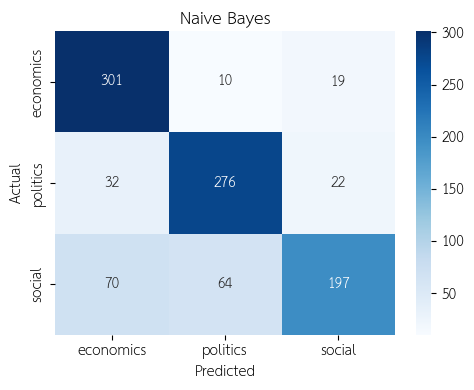

In [15]:
categories = sorted(y.unique())
n = len(trained_models)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
if n == 1:
    axes = [axes]

for ax, (name, model) in zip(axes, trained_models.items()):
    y_pred = model.predict(X_test_tfidf)
    print(f"\n{'=' * 50}")
    print(f"Model: {name}")
    print(classification_report(y_test, y_pred, target_names=categories))

    cm = confusion_matrix(y_test, y_pred, labels=categories)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=categories, yticklabels=categories, ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

## 7. Save Results

Saves trained models and metrics for reuse in Phase 4 (Evaluation & Application).

In [16]:
os.makedirs("artifacts", exist_ok=True)

# Save TF-IDF vectorizer
joblib.dump(tfidf, "artifacts/tfidf.joblib")

# Save each trained model
for name, model in trained_models.items():
    filename = name.lower().replace(" ", "_")
    joblib.dump(model, f"artifacts/{filename}.joblib")

# Save validation metrics
with open("results_classical.json", "w") as f:
    json.dump(results, f, indent=2)

print("Saved:")
print(f"  artifacts/tfidf.joblib")
for name in trained_models:
    print(f"  artifacts/{name.lower().replace(' ', '_')}.joblib")
print(f"  results_classical.json")

Saved:
  artifacts/tfidf.joblib
  artifacts/naive_bayes.joblib
  results_classical.json
